# The effect of removing a clade on ghost transfers

In [10]:
from ete3 import Tree
import os


original_dir = os.getcwd()

In [ ]:
from ete3 import Tree
import numpy as np
import os
import subprocess
import shutil
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm  # For the progress bar

# New directories
original_dir = os.getcwd()
experiment1_dir = "experiment1_data"
output_directory = f"{experiment1_dir}/output_directory"
pruned_trees_dir = f"{experiment1_dir}/pruned_trees"
reconciliations_dir = f"{experiment1_dir}/reconciliations"
transfers_file = f"{experiment1_dir}/transfers_file.txt"

# Ensure all directories exist
os.makedirs(experiment1_dir, exist_ok=True)
os.makedirs(output_directory, exist_ok=True)
os.makedirs(pruned_trees_dir, exist_ok=True)
os.makedirs(reconciliations_dir, exist_ok=True)

# Step 1: Generate the species tree using R script
def generate_species_tree(seed, n, b, d, file_path_complete, r_script_path):
    """
    Calls an R script to generate a phylogenetic tree and outputs the sum of branch lengths.
    """
    cmd = [
        "Rscript", r_script_path,
        str(n), str(b), str(d), file_path_complete, str(seed)
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except subprocess.CalledProcessError as e:
        print(f"Error occurred while calling R script: {e.stderr}")
        raise

species_tree_file = f"{experiment1_dir}/species_tree.nwk"
r_script_path = "generate_sp_tree.R"
sum_lengths = generate_species_tree(42, 50, 1.0, 0.0, species_tree_file, r_script_path)
print(f"Sum of branch lengths: {sum_lengths}")

# Step 2: Rename species to unique identifiers
def rename_species(tree):
    i = 10000
    for node in tree.traverse(strategy="postorder"):
        node.name = str(i)
        i += 1
    return tree

tree = Tree(species_tree_file, format=1)
tree = rename_species(tree)
renamed_tree_file = f"{experiment1_dir}/species_tree_renamed.nwk"
tree.write(outfile=renamed_tree_file, format=1, format_root_node=True)

# Step 3: Prune the tree
clade_to_remove = tree.search_nodes(name="10017")[0]
leaves_to_remove = set(clade_to_remove.get_leaf_names())
leaves_to_keep = set(tree.get_leaf_names()) - leaves_to_remove
tree.prune(leaves_to_keep)
pruned_tree_file = f"{pruned_trees_dir}/species_tree_pruned.nwk"
tree.write(outfile=pruned_tree_file, format=1, format_root_node=True)

# Step 4: Generate transfers
num_transfers = 3
num_genes = 256
np.random.seed(42)
with open(transfers_file, "w+") as f:
    for _ in range(num_genes):
        f.write(f"{num_transfers},")

# Step 5: Run the gene transfer simulation
cmd = [
    "./gene_transfer_script_",
    renamed_tree_file,
    output_directory,
    transfers_file,
    "42"
]
try:
    subprocess.run(cmd, capture_output=True, text=True, check=True)
except subprocess.CalledProcessError as e:
    print(f"Error occurred while calling transfers generator: {e.stderr}")
    raise

# Step 6: Prune gene trees
for i in range(num_genes):
    gene_tree_path = f"{output_directory}/tree_0/genes/gene_{i}.nwk"
    gene_tree = Tree(gene_tree_path, format=1)
    gene_tree.prune(leaves_to_keep)
    gene_tree.write(
        outfile=f"{pruned_trees_dir}/gene_{i}.nwk",
        format=1,
        format_root_node=True
    )
# shutil.copy(pruned_tree_file, f"{pruned_trees_dir}/species_tree_pruned.nwk")

# Step 7: Run ALEobserve and ALEml_undated
subprocess.run(f"ALEobserve {pruned_trees_dir}/species_tree_pruned.nwk",
               shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
os.chdir(pruned_trees_dir)
subprocess.run(
    f"ALEml_undated species_tree_pruned.nwk "
    f"species_tree_pruned.nwk.ale "
    "output_species_tree=y sample=0 delta=0 tau=0 lambda=0 seed=42",
    shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE
)
os.chdir(original_dir)
# Copy prepared species tree
shutil.copy(
    f"{pruned_trees_dir}/species_tree_pruned.nwk_species_tree_pruned.nwk.ale.spTree",
    f"{pruned_trees_dir}/prepared_species_tree.nwk"
)

# ALEobserve gene trees
for i in range(num_genes):
    gene_path = f"{pruned_trees_dir}/gene_{i}.nwk"
    subprocess.run(f"ALEobserve {gene_path}", shell=True)
    shutil.copy(f"{gene_path}.ale", f"{pruned_trees_dir}/prepared_gene_{i}.nwk")

os.chdir(experiment1_dir)
# Step 8: Reconciliation
def run_subprocess(i):
    cmd = f"ALEml_undated pruned_trees/prepared_species_tree.nwk pruned_trees/prepared_gene_{i}.nwk seed=42"
    try:
        subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        shutil.move(
            f"prepared_species_tree.nwk_prepared_gene_{i}.nwk.uml_rec",
            f"reconciliations/reconciliation_{i}.uml_rec"
        )
        shutil.move(
            f"prepared_species_tree.nwk_prepared_gene_{i}.nwk.uTs",
            f"reconciliations/reconciliation_{i}.uTs"
        )
    except subprocess.CalledProcessError as e:
        print(f"Gene {i} failed: {e.stderr.decode()}")

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(run_subprocess, i): i for i in range(num_genes)}
    for _ in tqdm(as_completed(futures), total=len(futures), desc="Processing genes"):
        pass
os.chdir(original_dir)

# Step 9: Analyze Results
import os
import pandas as pd
import re
import subprocess
import matplotlib.pyplot as plt

def remove_parentheses(s):
    """Ensure consistent formatting of names by removing parentheses."""
    if not isinstance(s, str):
        s = str(s)
    return re.sub(r"\([^)]*\)", "", s)

def strip_df(df):
    """Clean the Donor and Receiver columns."""
    df["Donor"] = df["Donor"].apply(remove_parentheses)
    df["Receiver"] = df["Receiver"].apply(remove_parentheses)
    return df

def transfers_df_fn(base_folder_path):
    """
    Process all .uTs reconciliation files in the specified folder.

    Parameters:
        base_folder_path (str): Folder containing reconciliation files.

    Returns:
        pd.DataFrame: DataFrame combining all reconciliation files.
    """
    temp_dfs = []
    pattern = re.compile(r"reconciliation_(\d+)\.uTs")

    for filename in os.listdir(base_folder_path):
        if filename.endswith(".uTs"):
            match = re.match(pattern, filename)
            if match:
                gene_index = int(match.group(1))
                file_path = os.path.join(base_folder_path, filename)
                corrected_file_path = f"{file_path}.corrected"

                # Use sed to clean the file
                sed_command = ['sed', 's/^[ \t]*//', file_path]
                with open(corrected_file_path, 'w') as corrected_file:
                    subprocess.run(sed_command, stdout=corrected_file)

                try:
                    # Read the corrected file
                    temp_df = pd.read_csv(
                        corrected_file_path,
                        sep='\t',
                        comment='#',
                        skiprows=1,  # Skip header row
                        header=None,
                        names=['Donor', 'Receiver', 'Frequency'],
                        skipinitialspace=True
                    )
                    temp_df['Gene_Index'] = gene_index
                    temp_dfs.append(temp_df)
                except pd.errors.ParserError as e:
                    print(f"Error reading {corrected_file_path}: {e}")
                finally:
                    os.remove(corrected_file_path)

    return pd.concat(temp_dfs, ignore_index=True) if temp_dfs else pd.DataFrame()

# Process the reconciliations for Experiment 1
reconciliations_dir = f"{experiment1_dir}/reconciliations"
df = transfers_df_fn(reconciliations_dir)

# Clean the DataFrame
df = strip_df(df)
df.to_csv(f"{experiment1_dir}/full_transfers.csv", index=False)

# Plotting
donor_transfers_df = df.groupby('Donor')['Frequency'].sum().reset_index()
donor_transfers_df.rename(columns={"Frequency": "Transfers"}, inplace=True)
from ete3 import Tree
import pandas as pd

# Function to add ale_name to sampled_tree nodes
def translate_trees(sampled_tree, ale_sampled_tree):
    """
    Adds an `ale_name` attribute to each node in `sampled_tree` by matching it with the corresponding node in `ale_sampled_tree`.

    Parameters:
        sampled_tree (Tree): The first tree with arbitrary internal node names.
        ale_sampled_tree (Tree): The second tree with `ale_name` to be transferred.
    """
    for node in sampled_tree.traverse(strategy="postorder"):
        if node.is_leaf():
            ale_node = ale_sampled_tree & node.name
            node.add_features(ale_name=ale_node.name)
        else:
            ale_node_child = ale_sampled_tree & node.get_children()[0].ale_name
            ale_node = ale_node_child.up
            node.add_features(ale_name=ale_node.name)

# Load sampled_tree and ale_sampled_tree
sampled_tree_file = f"{pruned_trees_dir}/species_tree_pruned.nwk"
ale_species_tree_file = f"{pruned_trees_dir}/prepared_species_tree.nwk"

sampled_tree = Tree(sampled_tree_file, format=1)
ale_species_tree = Tree(ale_species_tree_file, format=1)

# Translate trees to add ale_name
translate_trees(sampled_tree, ale_species_tree)
translation_dict = {node.ale_name: node.name for node in sampled_tree.traverse() if node.name}
donor_transfers_df["original_name"] = donor_transfers_df["Donor"].map(translation_dict)

node_distances = {node.ale_name: node.dist for node in sampled_tree.traverse() if node.name}
donor_transfers_df["Branch_Length"] = donor_transfers_df["Donor"].map(node_distances)

# Identify the special donor to highlight
special_donor = "10000"

# Separate data for conditional coloring
highlight_data = donor_transfers_df[donor_transfers_df["Donor"] == special_donor]
regular_data = donor_transfers_df[donor_transfers_df["Donor"] != special_donor]

plt.figure(figsize=(20, 12))

# Plot regular nodes
plt.scatter(
    regular_data["Branch_Length"],
    regular_data["Transfers"],
    color="blue",  # Regular nodes in blue
    label="Other Nodes"
)

# Plot the special node
plt.scatter(
    highlight_data["Branch_Length"],
    highlight_data["Transfers"],
    color="red",  # Special node in red
    label=f"Induced donor"
)


# Annotate all points
for _, row in donor_transfers_df.iterrows():
    plt.text(row["Branch_Length"], row["Transfers"], str(row["original_name"]), fontsize=12, ha="right")

# Add labels and title
plt.xlabel("Branch Length (node.dist)")
plt.ylabel("Transfers")
plt.title("Transfers vs Branch Length")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
donor_transfers_df

# Sampling leaves uniformly
Here we create ghost species by removing some species from the tree.

In [15]:
os.chdir(original_dir)

In [ ]:
from ete3 import Tree
import numpy as np
import os
import subprocess
import shutil
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm  # For the progress bar
import matplotlib.pyplot as plt

# New directories for Experiment 2
original_dir = os.getcwd()
experiment2_dir = "experiment2_data"
output_directory = f"{experiment2_dir}/output_directory"
pruned_trees_dir = f"{experiment2_dir}/pruned_trees"
reconciliations_dir = f"{experiment2_dir}/reconciliations"
transfers_file = f"{experiment2_dir}/transfers_file_uniform.txt"

# Ensure all directories exist
os.makedirs(experiment2_dir, exist_ok=True)
os.makedirs(output_directory, exist_ok=True)
os.makedirs(pruned_trees_dir, exist_ok=True)
os.makedirs(reconciliations_dir, exist_ok=True)

try:
    shutil.copy(f"experiment1_data/species_tree.nwk", f"{experiment2_dir}/species_tree.nwk")
except FileNotFoundError:
    print("Species tree not found. Please run Experiment 1 first.")
    raise FileNotFoundError

# Step 1: Load the species tree from Experiment 1
species_tree_file = "experiment1_data/species_tree.nwk"
tree = Tree(species_tree_file, format=1)

# Step 2: Rename species to unique identifiers
def rename_species(tree):
    i = 10000
    for node in tree.traverse(strategy="postorder"):
        node.name = str(i)
        i += 1
    return tree

tree = rename_species(tree)
renamed_tree_file = f"{experiment2_dir}/species_tree_renamed_uniform.nwk"
tree.write(outfile=renamed_tree_file, format=1, format_root_node=True)

# Step 3: Uniformly select 30 leaves to keep
np.random.seed(42)  # For reproducibility
leaves = tree.get_leaf_names()
leaves_to_keep = np.random.choice(leaves, 30, replace=False).tolist()
tree.prune(leaves_to_keep)
pruned_tree_file = f"{pruned_trees_dir}/species_tree_pruned.nwk"
tree.write(outfile=pruned_tree_file, format=1, format_root_node=True)

# Step 4: Generate transfers
num_transfers = 3
num_genes = 256

with open(transfers_file, "w+") as f:
    for _ in range(num_genes):
        f.write(f"{num_transfers},")

# Step 5: Run the gene transfer simulation
cmd = [
    "./gene_transfer_script_",
    renamed_tree_file,
    output_directory,
    transfers_file,
    "42"
]
try:
    subprocess.run(cmd, capture_output=True, text=True, check=True)
except subprocess.CalledProcessError as e:
    print(f"Error occurred while calling transfers generator: {e.stderr}")
    raise

# Step 6: Prune gene trees and save results
for i in range(num_genes):
    gene_tree_path = f"{output_directory}/tree_0/genes/gene_{i}.nwk"
    gene_tree = Tree(gene_tree_path, format=1)
    gene_tree.prune(leaves_to_keep)
    gene_tree.write(
        outfile=f"{pruned_trees_dir}/gene_{i}.nwk", format=1, format_root_node=True
    )

# Step 7: Run ALEobserve and ALEml_undated
subprocess.run(f"ALEobserve {pruned_trees_dir}/species_tree_pruned.nwk",
               shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)

os.chdir(pruned_trees_dir)
subprocess.run(
    f"ALEml_undated species_tree_pruned.nwk "
    f"species_tree_pruned.nwk.ale "
    "output_species_tree=y sample=0 delta=0 tau=0 lambda=0 seed=42",
    shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE
)
os.chdir(original_dir)

# Copy prepared species tree
shutil.copy(
    f"{pruned_trees_dir}/species_tree_pruned.nwk_species_tree_pruned.nwk.ale.spTree",
    f"{pruned_trees_dir}/prepared_species_tree.nwk"
)

# ALEobserve gene trees
for i in range(num_genes):
    gene_path = f"{pruned_trees_dir}/gene_{i}.nwk"
    subprocess.run(f"ALEobserve {gene_path}", shell=True)
    shutil.copy(f"{gene_path}.ale", f"{pruned_trees_dir}/prepared_gene_{i}.nwk")

# Step 8: Reconciliation
def run_subprocess(i):
    cmd = f"ALEml_undated {pruned_trees_dir}/prepared_species_tree.nwk {pruned_trees_dir}/prepared_gene_{i}.nwk seed=42"
    try:
        subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        shutil.move(
            f"prepared_species_tree.nwk_prepared_gene_{i}.nwk.uml_rec",
            f"{reconciliations_dir}/reconciliation_{i}.uml_rec"
        )
        shutil.move(
            f"prepared_species_tree.nwk_prepared_gene_{i}.nwk.uTs",
            f"{reconciliations_dir}/reconciliation_{i}.uTs"
        )
    except subprocess.CalledProcessError as e:
        print(f"Gene {i} failed: {e.stderr.decode()}")

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(run_subprocess, i): i for i in range(num_genes)}
    for _ in tqdm(as_completed(futures), total=len(futures), desc="Processing genes"):
        pass

# Step 9: Analyze Results
def remove_parentheses(s):
    """Ensure consistent formatting of names by removing parentheses."""
    if not isinstance(s, str):
        s = str(s)
    return re.sub(r"\([^)]*\)", "", s)

def strip_df(df):
    """Clean the Donor and Receiver columns."""
    df["Donor"] = df["Donor"].apply(remove_parentheses)
    df["Receiver"] = df["Receiver"].apply(remove_parentheses)
    return df

def transfers_df_fn(base_folder_path):
    """
    Process all .uTs reconciliation files in the specified folder.

    Parameters:
        base_folder_path (str): Folder containing reconciliation files.

    Returns:
        pd.DataFrame: DataFrame combining all reconciliation files.
    """
    temp_dfs = []
    pattern = re.compile(r"reconciliation_(\d+)\.uTs")

    for filename in os.listdir(base_folder_path):
        if filename.endswith(".uTs"):
            match = re.match(pattern, filename)
            if match:
                gene_index = int(match.group(1))
                file_path = os.path.join(base_folder_path, filename)
                corrected_file_path = f"{file_path}.corrected"

                # Use sed to clean the file
                sed_command = ['sed', 's/^[ \t]*//', file_path]
                with open(corrected_file_path, 'w') as corrected_file:
                    subprocess.run(sed_command, stdout=corrected_file)

                try:
                    # Read the corrected file
                    temp_df = pd.read_csv(
                        corrected_file_path,
                        sep='\t',
                        comment='#',
                        skiprows=1,  # Skip header row
                        header=None,
                        names=['Donor', 'Receiver', 'Frequency'],
                        skipinitialspace=True
                    )
                    temp_df['Gene_Index'] = gene_index
                    temp_dfs.append(temp_df)
                except pd.errors.ParserError as e:
                    print(f"Error reading {corrected_file_path}: {e}")
                finally:
                    os.remove(corrected_file_path)

    return pd.concat(temp_dfs, ignore_index=True) if temp_dfs else pd.DataFrame()

reconciliations_dir = f"{experiment2_dir}/reconciliations"
df = transfers_df_fn(reconciliations_dir)
df = strip_df(df)
df.to_csv(f"{experiment2_dir}/full_transfers_uniform.csv", index=False)

# Analyze and Plot
donor_transfers_df = df.groupby("Donor")["Frequency"].sum().reset_index()
donor_transfers_df.rename(columns={"Frequency": "Transfers"}, inplace=True)

tree = Tree(f"{pruned_trees_dir}/prepared_species_tree.nwk", format=1)
node_distances = {node.name: node.dist for node in tree.traverse() if node.name}
donor_transfers_df["Branch_Length"] = donor_transfers_df["Donor"].map(node_distances)

sampled_tree = "experiment2_data/pruned_trees/species_tree_pruned.nwk"
complete_tree = "experiment2_data/species_tree_renamed_uniform.nwk"
sampled_tree = Tree(sampled_tree, format=1)
complete_tree = Tree(complete_tree, format=1)

def is_part_of_sampled_tree(complete_tree, sampled_tree):
    """This function takes a complete tree and a sampled tree and marks nodes that are either present in the sampled tree,
    or which have a descendant that is present in the sampled tree."""
    sampled_tree_nodes = set([n.name for n in sampled_tree.traverse()])

    for node in complete_tree.traverse():
        descendants = node.get_descendants()
        if node.name in sampled_tree_nodes:
            node.add_features(in_sampled_tree = 1)
        elif any(descendant.name in sampled_tree_nodes for descendant in descendants):
            # Not part of the sampled tree, but has a descendant that is.
            node.add_features(in_sampled_tree = 2)
        else:
            node.add_features(in_sampled_tree = 0)
    return complete_tree, sampled_tree


def lists_to_tensors(sampled_tree):
    """Makes the times_list attribute of each node in the sampled tree a tensor.
    Returns the sampled tree."""
    for node in sampled_tree.traverse():
        node.add_features(times_list=np.array(node.times_list, dtype=np.float32))
    return sampled_tree

def process_trees(complete_tree, sampled_tree):
    """Attributes the ghost nodes' times to the corresponding nodes in the sampled tree."""
    # Initialize an empty times_list attribute for each node in the sampled tree
    for node in sampled_tree.traverse():
        node.add_features(times_list=[])
        node.add_features(ghost_descendants=[])
        node.add_features(LTT_variation = []) # List of +1 or -1, depending on whether the ghost node is terminal (lowering the LTT) or internal (increasing the LTT by 1)

    for node in complete_tree.traverse():
        # If the node is in the sampled tree, we do nothing. 
        # If the node has a descendant in the sampled tree, but is not in the sampled tree, we find the node it attaches to in the sampled tree.
        # If the node is not in the sampled tree and has no descendant in the sampled tree, we need to find which node in the sampled tree it attaches to.
        # If the node is a leaf, then either it is part of the sampled tree, in which case it is not added as a ghost tree, or 
        # it is not part of the sampled tree, and it should be counted as a death. When a ghost branch G stemming from a branch B
        # dies at time t, the "ghost LTT" of the branch B decreases by 1 at time t.
        if node.in_sampled_tree != 1:#In this case, the node is not in the sampled tree, so it counts as a ghost branch
            if node.in_sampled_tree == 0:#In this case either the node's sister has a descendant in the sampled tree it will attach on, or we must move up to find the parent's sibling
                sibling = node.get_sisters()[0] if node.get_sisters() else None
            elif node.in_sampled_tree == 2:
                sibling = node.get_children()[0] if node.get_children()[0].in_sampled_tree!=0 else node.get_children()[1]

            # if the sibling is in the sampled tree, then we just append to it (and we don't get in the loop)
            # else, if the sibling has a descendant in the sampled tree, then we append to the descendant (and we don't get in the loop)
            # While sibling's in_sampled_tree is not 1
            while sibling and sibling.in_sampled_tree != 1:
                # If sibling's in_sampled_tree is 0, move up to parent's sibling. In this case, the sibling does not have an extant descendent either
                if sibling.in_sampled_tree == 0:
                    sibling = sibling.up.get_sisters()[0] if sibling.up and sibling.up.get_sisters() else None

                # If sibling's in_sampled_tree is 2, move down to children. In this case, it should only have one child with an extant descendent
                elif sibling.in_sampled_tree == 2:
                    siblings = sibling.get_children()
                    sibling = siblings[0] if siblings[0].in_sampled_tree!=0 else siblings[1]

            # If we found a sibling in the sampled tree
            if sibling and sibling.in_sampled_tree == 1:
                # Get the node in the sampled tree corresponding to the sibling
                sampled_tree_node = sampled_tree&sibling.name
                # Append the node's distance to the root to the sibling's times_list attribute
                sampled_tree_node.times_list.append(node.get_distance(complete_tree))
                sampled_tree_node.ghost_descendants.append((node.name, node.get_distance(complete_tree)))
                sampled_tree_node.LTT_variation.append(-1 if node.is_leaf() else 1)
                node.add_features(sampled_tree_parent = sibling.name)
    # Return the processed sampled tree
    return lists_to_tensors(sampled_tree)

def compute_ghost_length(times_list, LTT_variation, time_endpoint):
    """
    times_list is the list of times at which a branch either splits or goes extinct.
    LTT_variation is a vector with values in {1, -1}, indicating whether the given time
    corresponds to an extinction or a split.
    
    We can compute the ghost length in the following way: when a branch splits, we count it as 
    +1*(time_endpoint - time_split), and when a branch dies, we count it as -1*(time_endpoint - time_split) 
    """
    # First compute the list of the intervals.
    np_events = time_endpoint - np.array(times_list)
    np_LTT_variation = np.array(LTT_variation, dtype = float)
    return np.dot(np_events, np_LTT_variation)

def assign_ghost_lengths(sampled_tree):
    """Every node needs to have attributes event_times, and LTT_variation"""
    time_endpoint = sampled_tree.get_farthest_leaf()[1]
    for node in sampled_tree.traverse():
        node.add_features(ghost_length = compute_ghost_length(node.times_list,
                                                              node.LTT_variation,
                                                              time_endpoint))
        
    return sampled_tree

def translate_trees(sampled_tree, ale_sampled_tree):
    """
    Adds an ale_name attribute to each node in sampled_tree by matching it with the corresponding node in ale_sampled_tree.

    Parameters:
        sampled_tree (Tree): The first tree with arbitrary internal node names.
        ale_sampled_tree (Tree): The second tree with ale_name to be transferred.
    """
    for node in sampled_tree.traverse(strategy="postorder"):
        if node.is_leaf():
            ale_node = ale_sampled_tree & node.name
            node.add_features(ale_name=ale_node.name)
        else:
            ale_node_child = ale_sampled_tree & node.get_children()[0].ale_name
            ale_node = ale_node_child.up
            node.add_features(ale_name=ale_node.name)

is_part_of_sampled_tree(complete_tree, sampled_tree)
process_trees(complete_tree, sampled_tree)
assign_ghost_lengths(sampled_tree)
ale_species_tree = Tree("experiment2_data/pruned_trees/prepared_species_tree.nwk", format=1)
translate_trees(sampled_tree, ale_species_tree)

import os
import pandas as pd
import re
import subprocess

def remove_parentheses(s):
    if not isinstance(s, str):  # Ensure s is a string
        s = str(s)
    return re.sub(r"\([^)]*\)", "", s)

def strip_df(df):
    """Clean the Donor and Receiver columns."""
    df["Donor"] = df["Donor"].apply(remove_parentheses)
    df["Receiver"] = df["Receiver"].apply(remove_parentheses)
    return df

def transfers_df_fn(base_folder_path):
    """
    Process all .uTs reconciliation files in the specified folder.

    Parameters:
        base_folder_path (str): Folder containing reconciliation files.

    Returns:
        pd.DataFrame: DataFrame combining all reconciliation files.
    """
    temp_dfs = []
    pattern = re.compile(r"reconciliation_(\d+)\.uTs")

    for filename in os.listdir(base_folder_path):
        if filename.endswith(".uTs"):
            match = re.match(pattern, filename)
            if match:
                gene_index = int(match.group(1))
                file_path = os.path.join(base_folder_path, filename)
                corrected_file_path = f"{file_path}.corrected"

                # Use sed to clean the file
                sed_command = ['sed', 's/^[ \t]*//', file_path]
                with open(corrected_file_path, 'w') as corrected_file:
                    subprocess.run(sed_command, stdout=corrected_file)

                try:
                    # Read the corrected file
                    temp_df = pd.read_csv(
                        corrected_file_path,
                        sep='\t',
                        comment='#',
                        skiprows=1,  # Skip header row
                        header=None,
                        names=['Donor', 'Receiver', 'Frequency'],
                        skipinitialspace=True
                    )
                    temp_df['Gene_Index'] = gene_index
                    temp_dfs.append(temp_df)
                except pd.errors.ParserError as e:
                    print(f"Error reading {corrected_file_path}: {e}")
                finally:
                    os.remove(corrected_file_path)

    return pd.concat(temp_dfs, ignore_index=True) if temp_dfs else pd.DataFrame()

# Process the reconciliations for the second experiment
reconciliations_dir = "experiment2_data/reconciliations"
df = transfers_df_fn(reconciliations_dir)

# Clean the DataFrame
df = strip_df(df)
df.to_csv("experiment2_data/full_transfers_uniform.csv", index=False)

# Analyze and Plot
donor_transfers_df = df.groupby("Donor")["Frequency"].sum().reset_index()
donor_transfers_df.rename(columns={"Frequency": "Transfers"}, inplace=True)

# Collect branch lengths from the species tree
from ete3 import Tree
tree = Tree("experiment2_data/pruned_trees/prepared_species_tree.nwk", format=1)
node_distances = {node.name: node.dist for node in tree.traverse() if node.name}
donor_transfers_df["Branch_Length"] = donor_transfers_df["Donor"].map(node_distances)

# Plot Transfers vs Branch Length
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plt.scatter(donor_transfers_df["Branch_Length"], donor_transfers_df["Transfers"])

# Annotate the scatter plot
for _, row in donor_transfers_df.iterrows():
    plt.text(row["Branch_Length"], row["Transfers"], str(row["Donor"]), fontsize=12, ha="right")

plt.xlabel("Branch Length (node.dist)")
plt.ylabel("Transfers")
plt.title("Transfers vs Branch Length (Uniform Leaves)")
plt.grid(True)
plt.show()


def add_ghost_length_to_df(donor_transfers_df, sampled_tree):
    """
    Add a column ghost_length to donor_transfers_df.
    The ghost_length is obtained by matching Donor with the ale_name
    of nodes in sampled_tree.

    Parameters:
        donor_transfers_df (pd.DataFrame): DataFrame containing the Donor column.
        sampled_tree (Tree): Tree with nodes annotated with ale_name and ghost_length.

    Returns:
        pd.DataFrame: Updated DataFrame with a new ghost_length column.
    """
    # Create a mapping from ale_name to ghost_length
    ale_name_to_ghost_length = {
        node.ale_name: getattr(node, 'ghost_length', None) for node in sampled_tree.traverse()
    }

    # Add the ghost_length column by mapping the Donor column
    donor_transfers_df['ghost_length'] = donor_transfers_df['Donor'].map(ale_name_to_ghost_length)

    return donor_transfers_df

# Example usage
# Assume donor_transfers_df is already loaded
# Assume sampled_tree has been annotated with ale_name and ghost_length
donor_transfers_df = add_ghost_length_to_df(donor_transfers_df, sampled_tree)

# Verify the updated DataFrame
print(donor_transfers_df.head())
import matplotlib.pyplot as plt

# Normalize ghost_length to control the marker size
size_scale = 100  # Adjust this value to control the marker size scaling
donor_transfers_df["Marker_Size"] = donor_transfers_df["ghost_length"].fillna(0) * size_scale

# Create the plot
plt.figure(figsize=(20, 12))
scatter = plt.scatter(
    donor_transfers_df["Branch_Length"],
    donor_transfers_df["Transfers"],
    s=donor_transfers_df["Marker_Size"],  # Marker size based on ghost_length
    alpha=0.7  # Optional transparency for better visibility
)

# Annotate the scatter plot with Donor names
for _, row in donor_transfers_df.iterrows():
    plt.text(row["Branch_Length"], row["Transfers"], str(row["Donor"]), fontsize=12, ha="right")

# Add labels and title
plt.xlabel("Branch Length (node.dist)")
plt.ylabel("Transfers")
plt.title("Transfers vs Branch Length (Uniform Leaves) with Ghost Length")
plt.grid(True)

# Display the plot
plt.show()


In [69]:
sampled_tree = "experiment2_data/pruned_trees/species_tree_pruned.nwk"
complete_tree = "experiment2_data/species_tree_renamed_uniform.nwk"
sampled_tree = Tree(sampled_tree, format=1)
complete_tree = Tree(complete_tree, format=1)

def is_part_of_sampled_tree(complete_tree, sampled_tree):
    """This function takes a complete tree and a sampled tree and marks nodes that are either present in the sampled tree,
    or which have a descendant that is present in the sampled tree."""
    sampled_tree_nodes = set([n.name for n in sampled_tree.traverse()])

    for node in complete_tree.traverse():
        descendants = node.get_descendants()
        if node.name in sampled_tree_nodes:
            node.add_features(in_sampled_tree = 1)
        elif any(descendant.name in sampled_tree_nodes for descendant in descendants):
            # Not part of the sampled tree, but has a descendant that is.
            node.add_features(in_sampled_tree = 2)
        else:
            node.add_features(in_sampled_tree = 0)
    return complete_tree, sampled_tree


def lists_to_tensors(sampled_tree):
    """Makes the times_list attribute of each node in the sampled tree a tensor.
    Returns the sampled tree."""
    for node in sampled_tree.traverse():
        node.add_features(times_list=np.array(node.times_list, dtype=np.float32))
    return sampled_tree

def process_trees(complete_tree, sampled_tree):
    """Attributes the ghost nodes' times to the corresponding nodes in the sampled tree."""
    # Initialize an empty times_list attribute for each node in the sampled tree
    for node in sampled_tree.traverse():
        node.add_features(times_list=[])
        node.add_features(ghost_descendants=[])
        node.add_features(LTT_variation = []) # List of +1 or -1, depending on whether the ghost node is terminal (lowering the LTT) or internal (increasing the LTT by 1)

    for node in complete_tree.traverse():
        # If the node is in the sampled tree, we do nothing. 
        # If the node has a descendant in the sampled tree, but is not in the sampled tree, we find the node it attaches to in the sampled tree.
        # If the node is not in the sampled tree and has no descendant in the sampled tree, we need to find which node in the sampled tree it attaches to.
        # If the node is a leaf, then either it is part of the sampled tree, in which case it is not added as a ghost tree, or 
        # it is not part of the sampled tree, and it should be counted as a death. When a ghost branch G stemming from a branch B
        # dies at time t, the "ghost LTT" of the branch B decreases by 1 at time t.
        if node.in_sampled_tree != 1:#In this case, the node is not in the sampled tree, so it counts as a ghost branch
            if node.in_sampled_tree == 0:#In this case either the node's sister has a descendant in the sampled tree it will attach on, or we must move up to find the parent's sibling
                sibling = node.get_sisters()[0] if node.get_sisters() else None
            elif node.in_sampled_tree == 2:
                sibling = node.get_children()[0] if node.get_children()[0].in_sampled_tree!=0 else node.get_children()[1]

            # if the sibling is in the sampled tree, then we just append to it (and we don't get in the loop)
            # else, if the sibling has a descendant in the sampled tree, then we append to the descendant (and we don't get in the loop)
            # While sibling's in_sampled_tree is not 1
            while sibling and sibling.in_sampled_tree != 1:
                # If sibling's in_sampled_tree is 0, move up to parent's sibling. In this case, the sibling does not have an extant descendent either
                if sibling.in_sampled_tree == 0:
                    sibling = sibling.up.get_sisters()[0] if sibling.up and sibling.up.get_sisters() else None

                # If sibling's in_sampled_tree is 2, move down to children. In this case, it should only have one child with an extant descendent
                elif sibling.in_sampled_tree == 2:
                    siblings = sibling.get_children()
                    sibling = siblings[0] if siblings[0].in_sampled_tree!=0 else siblings[1]

            # If we found a sibling in the sampled tree
            if sibling and sibling.in_sampled_tree == 1:
                # Get the node in the sampled tree corresponding to the sibling
                sampled_tree_node = sampled_tree&sibling.name
                # Append the node's distance to the root to the sibling's times_list attribute
                sampled_tree_node.times_list.append(node.get_distance(complete_tree))
                sampled_tree_node.ghost_descendants.append((node.name, node.get_distance(complete_tree)))
                sampled_tree_node.LTT_variation.append(-1 if node.is_leaf() else 1)
                node.add_features(sampled_tree_parent = sibling.name)
    # Return the processed sampled tree
    return lists_to_tensors(sampled_tree)

def compute_ghost_length(times_list, LTT_variation, time_endpoint):
    """
    times_list is the list of times at which a branch either splits or goes extinct.
    LTT_variation is a vector with values in {1, -1}, indicating whether the given time
    corresponds to an extinction or a split.
    
    We can compute the ghost length in the following way: when a branch splits, we count it as 
    +1*(time_endpoint - time_split), and when a branch dies, we count it as -1*(time_endpoint - time_split) 
    """
    # First compute the list of the intervals.
    np_events = time_endpoint - np.array(times_list)
    np_LTT_variation = np.array(LTT_variation, dtype = float)
    return np.dot(np_events, np_LTT_variation)

def assign_ghost_lengths(sampled_tree):
    """Every node needs to have attributes event_times, and LTT_variation"""
    time_endpoint = sampled_tree.get_farthest_leaf()[1]
    for node in sampled_tree.traverse():
        node.add_features(ghost_length = compute_ghost_length(node.times_list,
                                                              node.LTT_variation,
                                                              time_endpoint))
        
    return sampled_tree

def translate_trees(sampled_tree, ale_sampled_tree):
    """
    Adds an ale_name attribute to each node in sampled_tree by matching it with the corresponding node in ale_sampled_tree.

    Parameters:
        sampled_tree (Tree): The first tree with arbitrary internal node names.
        ale_sampled_tree (Tree): The second tree with ale_name to be transferred.
    """
    for node in sampled_tree.traverse(strategy="postorder"):
        if node.is_leaf():
            ale_node = ale_sampled_tree & node.name
            node.add_features(ale_name=ale_node.name)
        else:
            ale_node_child = ale_sampled_tree & node.get_children()[0].ale_name
            ale_node = ale_node_child.up
            node.add_features(ale_name=ale_node.name)

complete_tree, sampled_tree = is_part_of_sampled_tree(complete_tree, sampled_tree)
process_trees(complete_tree, sampled_tree)
assign_ghost_lengths(sampled_tree)
ale_species_tree = Tree("experiment2_data/pruned_trees/prepared_species_tree.nwk", format=1)
translate_trees(sampled_tree, ale_species_tree)
translation_dict = {node.ale_name: node.name for node in sampled_tree.traverse()}

import os
import pandas as pd
import re
import subprocess

def remove_parentheses(s):
    if not isinstance(s, str):  # Ensure s is a string
        s = str(s)
    return re.sub(r"\([^)]*\)", "", s)

def strip_df(df):
    """Clean the Donor and Receiver columns."""
    df["Donor"] = df["Donor"].apply(remove_parentheses)
    df["Receiver"] = df["Receiver"].apply(remove_parentheses)
    return df

def transfers_df_fn(base_folder_path):
    """
    Process all .uTs reconciliation files in the specified folder.

    Parameters:
        base_folder_path (str): Folder containing reconciliation files.

    Returns:
        pd.DataFrame: DataFrame combining all reconciliation files.
    """
    temp_dfs = []
    pattern = re.compile(r"reconciliation_(\d+)\.uTs")

    for filename in os.listdir(base_folder_path):
        if filename.endswith(".uTs"):
            match = re.match(pattern, filename)
            if match:
                gene_index = int(match.group(1))
                file_path = os.path.join(base_folder_path, filename)
                corrected_file_path = f"{file_path}.corrected"

                # Use sed to clean the file
                sed_command = ['sed', 's/^[ \t]*//', file_path]
                with open(corrected_file_path, 'w') as corrected_file:
                    subprocess.run(sed_command, stdout=corrected_file)

                try:
                    # Read the corrected file
                    temp_df = pd.read_csv(
                        corrected_file_path,
                        sep='\t',
                        comment='#',
                        skiprows=1,  # Skip header row
                        header=None,
                        names=['Donor', 'Receiver', 'Frequency'],
                        skipinitialspace=True
                    )
                    temp_df['Gene_Index'] = gene_index
                    temp_dfs.append(temp_df)
                except pd.errors.ParserError as e:
                    print(f"Error reading {corrected_file_path}: {e}")
                finally:
                    os.remove(corrected_file_path)

    return pd.concat(temp_dfs, ignore_index=True) if temp_dfs else pd.DataFrame()

# Process the reconciliations for the second experiment
reconciliations_dir = "experiment2_data/reconciliations"
df = transfers_df_fn(reconciliations_dir)

# Clean the DataFrame
df = strip_df(df)
df.to_csv("experiment2_data/full_transfers_uniform.csv", index=False)

# Analyze and Plot
donor_transfers_df = df.groupby("Donor")["Frequency"].sum().reset_index()
donor_transfers_df.rename(columns={"Frequency": "Transfers"}, inplace=True)

# Collect branch lengths from the species tree
from ete3 import Tree
tree = Tree("experiment2_data/pruned_trees/prepared_species_tree.nwk", format=1)
node_distances = {node.name: node.dist for node in tree.traverse() if node.name}
donor_transfers_df["Branch_Length"] = donor_transfers_df["Donor"].map(node_distances)
donor_transfers_df["original_name"] = donor_transfers_df["Donor"].map(translation_dict)


def add_ghost_length_to_df(donor_transfers_df, sampled_tree):
    """
    Add a column ghost_length to donor_transfers_df.
    The ghost_length is obtained by matching Donor with the ale_name
    of nodes in sampled_tree.

    Parameters:
        donor_transfers_df (pd.DataFrame): DataFrame containing the Donor column.
        sampled_tree (Tree): Tree with nodes annotated with ale_name and ghost_length.

    Returns:
        pd.DataFrame: Updated DataFrame with a new ghost_length column.
    """
    # Create a mapping from ale_name to ghost_length
    ale_name_to_ghost_length = {
        node.ale_name: getattr(node, 'ghost_length', None) for node in sampled_tree.traverse()
    }

    # Add the ghost_length column by mapping the Donor column
    donor_transfers_df['ghost_length'] = donor_transfers_df['Donor'].map(ale_name_to_ghost_length)

    return donor_transfers_df

# Example usage
# Assume donor_transfers_df is already loaded
# Assume sampled_tree has been annotated with ale_name and ghost_length
donor_transfers_df = add_ghost_length_to_df(donor_transfers_df, sampled_tree)

# Verify the updated DataFrame
print(donor_transfers_df.head())




   Donor  Transfers  Branch_Length original_name  ghost_length
0  10000      16.51        1.99460         10000       0.00000
1  10004       3.12        0.45315         10004       0.00000
2  10005       2.13        0.17424         10005       0.00000
3  10006       0.09        0.17424         10006       0.00000
4  10009       8.42        0.04511         10009       0.04511


/tmp/ipykernel_3571226/1049927336.py:184: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(temp_dfs, ignore_index=True) if temp_dfs else pd.DataFrame()


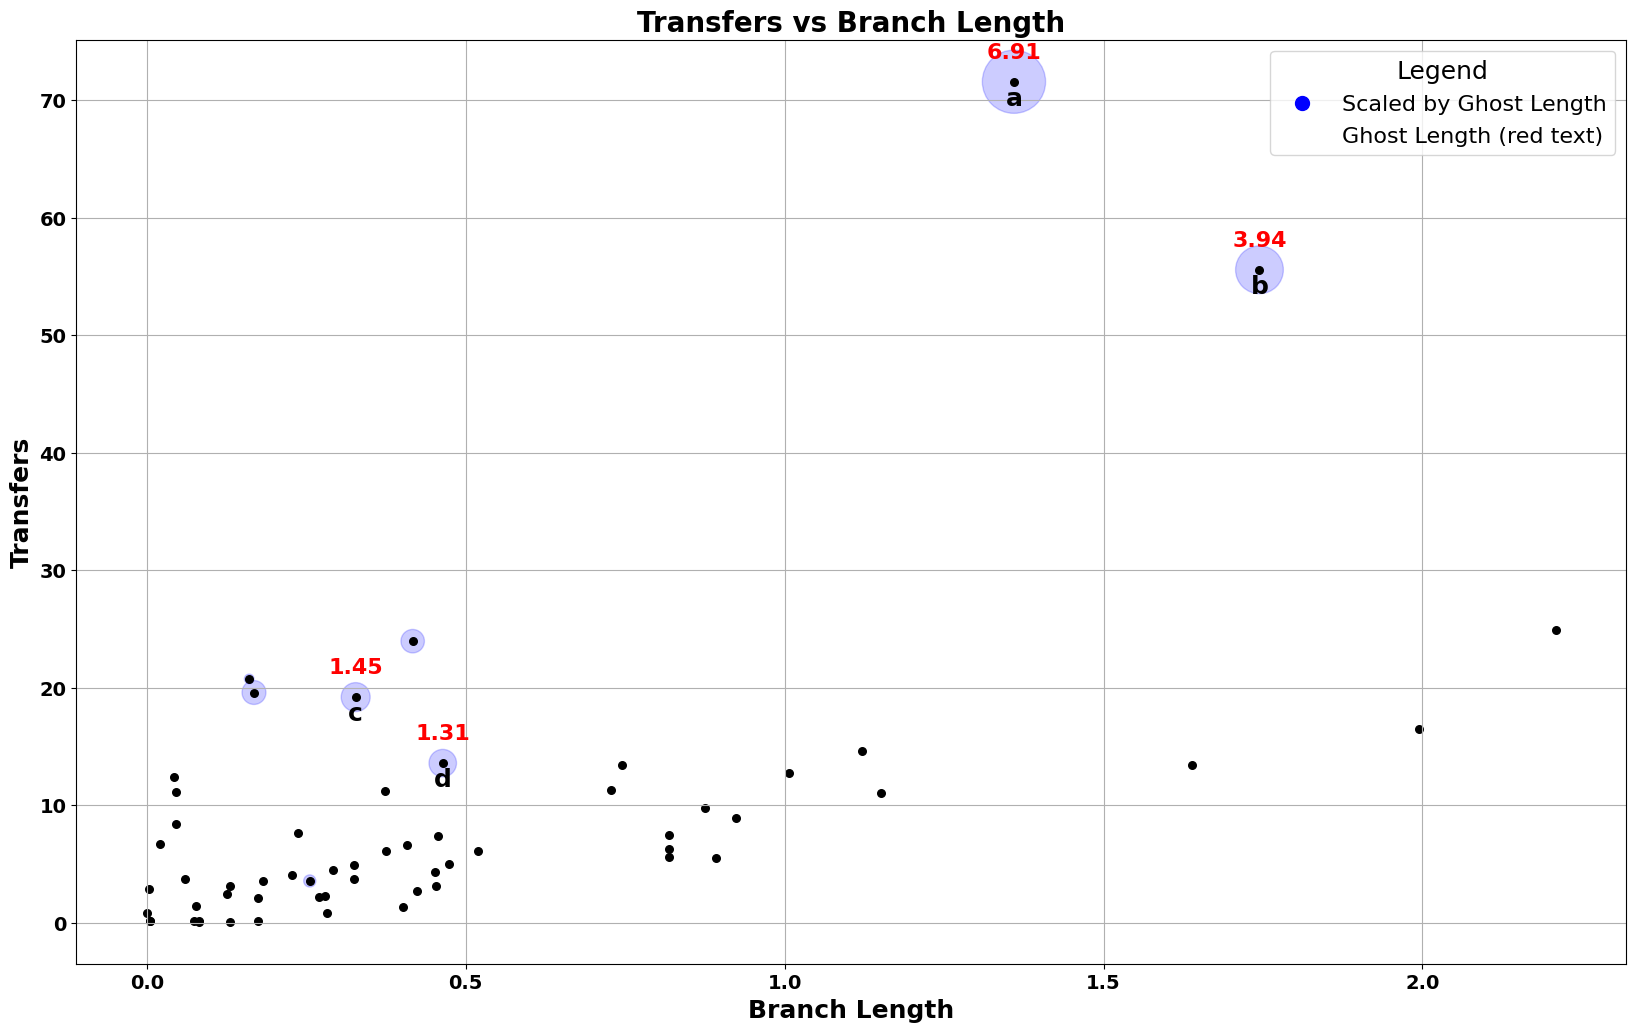

In [147]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import string

# Transform node names by subtracting 10000 and convert to strings
donor_transfers_df["original_name_2"] = donor_transfers_df["original_name"].apply(lambda x: str(int(x) - 10000))

# Normalize ghost_length to control the marker size
size_scale = 300  # Adjust this value to control marker sizes
donor_transfers_df["Marker_Size"] = donor_transfers_df["ghost_length"].fillna(0) * size_scale

# Filter nodes with ghost_length > 1 and sort them in descending order
high_ghost_nodes = donor_transfers_df[donor_transfers_df["ghost_length"] > 1].sort_values(by="ghost_length", ascending=False)
# Create a mapping of letters (a, b, c, ...) to these nodes
letter_mapping = {index: letter for index, letter in zip(high_ghost_nodes.index, string.ascii_lowercase)}

# Create the plot
plt.figure(figsize=(20, 12))

# Plot the scatter with discs scaled by ghost_length
scatter = plt.scatter(
    donor_transfers_df["Branch_Length"],
    donor_transfers_df["Transfers"],
    s=donor_transfers_df["Marker_Size"],  # Marker size based on ghost_length
    color="blue",
    alpha=0.2  # Optional transparency for better visibility
)

# Overlay smaller black dots at the center of each disc
plt.scatter(
    donor_transfers_df["Branch_Length"],
    donor_transfers_df["Transfers"],
    s=30,  # Fixed size for black dots
    color="black"
)

# Annotate only nodes with ghost_length > 1 using letters and ghost_length
for _, row in donor_transfers_df.iterrows():
    if row.name in letter_mapping:
        letter = letter_mapping[row.name]
        # Display the letter above the point
        plt.text(
            row["Branch_Length"],
            row["Transfers"] - 2,  # Slightly above the transfer value
            letter,
            fontsize=18,
            ha="center",
            fontweight="bold"
        )
        # Display the ghost length below the point
        plt.text(
            row["Branch_Length"],
            row["Transfers"] + 2,  # Slightly below the transfer value
            f"{row['ghost_length']:.2f}",
            fontsize=16,
            ha="center",
            color="red",
            fontweight="bold"
        )

# Add axis labels and title
plt.xlabel("Branch Length", fontsize=18, fontweight="bold")  # Bold and larger font for x-axis
plt.ylabel("Transfers", fontsize=18, fontweight="bold")  # Bold and larger font for y-axis
plt.title("Transfers vs Branch Length", fontsize=20, fontweight="bold")  # Title with bold font
plt.grid(True)  # Add a grid for better readability

# Add a legend for the red text and blue circles
legend_elements = [
    Line2D([], [], color='blue', marker='o', markersize=10, label='Scaled by Ghost Length', linestyle=''),
    Line2D([], [], color='red', marker='', label='Ghost Length (red text)', linestyle='', markersize=0)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=16, title="Legend", title_fontsize=18)  # Adjust legend size and title font

# Increase the font size and boldness of axis ticks
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

# Display the plot
plt.show()


In [ ]:

# nodes with highest ghost lengths: 52, 72, 93, 12 
sampled_tree.search_nodes(name="52")[0].name = "a"
sampled_tree.search_nodes(name="72")[0].name = "b"
sampled_tree.search_nodes(name="93")[0].name = "c"
sampled_tree.search_nodes(name="12")[0].name = "d"

In [75]:
# find nodes in complete tree corresponding to sampled tree, and attribute ghost length to them
for node in sampled_tree.traverse():
    complete_tree_node = complete_tree & node.name
    complete_tree_node.add_features(ghost_length=node.ghost_length)

In [79]:
from ete3 import Tree, TreeStyle, NodeStyle


# Define styles for branches
black_style = NodeStyle()
black_style["fgcolor"] = "black"  # Black color for branches
black_style["size"] = 0  # Hide node dots if not needed

red_style = NodeStyle()
red_style["fgcolor"] = "red"  # Red color for branches
red_style["size"] = 0  # Hide node dots if not needed

# Apply styles to the tree nodes based on in_sampled_tree
for node in complete_tree.traverse():
    if getattr(node, "in_sampled_tree", 0) == 1:  # If node.in_sampled_tree == 1
        node.set_style(black_style)
    else:  # All other nodes
        node.set_style(red_style)

# Configure TreeStyle
tree_style = TreeStyle()
tree_style.show_leaf_name = True  # Display leaf names
tree_style.branch_vertical_margin = 10  # Adjust spacing between branches

# Render the tree
complete_tree.show(tree_style=tree_style)


In [99]:
for node in complete_tree.traverse():
    print(node.name)

10098
10070
10097
10040
10069
10075
10096
10018
10039
10057
10068
10073
10074
10086
10095
10000
10017
10035
10038
10045
10056
10058
10067
10071
10072
10084
10085
10093
10094
10013
10016
10029
10034
10036
10037
10041
10044
10052
10055
10063
10066
10078
10083
10087
10092
10003
10012
10014
10015
10023
10028
10030
10033
10042
10043
10048
10051
10053
10054
10061
10062
10064
10065
10076
10077
10081
10082
10090
10091
10001
10002
10008
10011
10019
10022
10024
10027
10031
10032
10046
10047
10049
10050
10059
10060
10079
10080
10088
10089
10004
10007
10009
10010
10020
10021
10025
10026
10005
10006


In [129]:
from ete3 import Tree, TreeStyle, NodeStyle, faces, AttrFace
complete_tree_to_render = complete_tree.copy()
for node in complete_tree_to_render.traverse():
    # nodes with highest ghost lengths: 52, 72, 93, 12 
    if node.name == "10052":
        node.name = "a"
    elif node.name == "10072":
        node.name = "b"
    elif node.name == "10093":
        node.name = "c"
    elif node.name == "10012":
        node.name = "d"
    else:
        node.name = ""


# Define styles for branches
black_style = NodeStyle()
black_style["vt_line_color"] = "black"
black_style["hz_line_color"] = "black"
black_style["vt_line_width"] = 2
black_style["hz_line_width"] = 2
black_style["vt_line_type"] = 0
black_style["hz_line_type"] = 0

red_style = NodeStyle()
red_style["vt_line_color"] = "red"
red_style["hz_line_color"] = "red"
red_style["vt_line_width"] = 2
red_style["hz_line_width"] = 2
red_style["vt_line_type"] = 0
red_style["hz_line_type"] = 0

# Ensure all nodes have a valid name
for node in complete_tree_to_render.traverse():
    if getattr(node, "name", None) is None or node.name == "":
        node.name = "\u200B" # Zero-width space for empty names

    # Apply styles based on in_sampled_tree attribute
    if getattr(node, "in_sampled_tree", 0) in {1, 2}:
        node.img_style = black_style  # Use black for nodes in the sampled tree
    else:
        node.img_style = red_style  # Use red for all other nodes

# Define a custom layout function to show internal node names
def layout(node):
    if node.is_leaf() or not node.is_leaf():
        # Add the node name as a face
        faces.add_face_to_node(AttrFace("name", fsize=40), node, column=0)

# Create and configure TreeStyle
ts = TreeStyle()
ts.layout_fn = layout  # Use the custom layout function
ts.show_leaf_name = False  # Display leaf names
ts.show_branch_length = False  # Hide branch lengths
ts.show_branch_support = False  # Hide branch support values
ts.scale = 400  # Adjust scale for better visibility
ts.title.add_face(faces.TextFace("Tree Rendering with Branch Colors", fsize=12, bold=True), column=0)

# Render the tree to an image file
output_file = "complete_tree_rendered_with_internal_names.png"
complete_tree_to_render.render(output_file, tree_style=ts, w=1830, units="px")

print(f"Tree has been rendered and saved to {output_file}.")


Tree has been rendered and saved to complete_tree_rendered_with_internal_names.png.
